# 03 — Exploratory Data Analysis (EDA)

## Project
**AI Supply Chain Disruption Prediction + NLP News Signals + Digital Marketing Decision Layer**

This notebook performs exploratory analysis on the **cleaned datasets produced by `02_data_cleaning.ipynb`**.

### EDA rules
- Use only the supplied project datasets.
- Do not train predictive models here.
- Do not report model accuracy, F1, ROC-AUC, RMSE, or other model results.
- Do not create an artificial date for the news dataset.
- Do not delete observations simply because they are statistical outliers.
- Findings below are descriptive observations, not causal claims.


## Cell 1 — Imports and Paths

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
INTERIM = ROOT / "data" / "interim"
FIGURES = ROOT / "results" / "figures"

FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("INTERIM:", INTERIM)
print("FIGURES:", FIGURES)


INTERIM: c:\Users\ankit\Desktop\Ml-Project\AI-Supply-Chain-Digital-Marketing-v1\data\interim
FIGURES: c:\Users\ankit\Desktop\Ml-Project\AI-Supply-Chain-Digital-Marketing-v1\results\figures


## Cell 2 — Load Cleaned Main Datasets

In [3]:
supply = pd.read_csv(
    INTERIM / "cleaned_supply_chain.csv",
    parse_dates=["Date"]
)

marketing = pd.read_csv(
    INTERIM / "cleaned_marketing.csv",
    parse_dates=["Date"]
)

news = pd.read_csv(
    INTERIM / "cleaned_news.csv"
)

print("Supply chain:", supply.shape)
print("Marketing:", marketing.shape)
print("News:", news.shape)


Supply chain: (5000, 14)
Marketing: (200000, 16)
News: (4840, 2)


## Cell 3 — Load Cleaned Historical Trade Datasets

In [4]:
historical_files = [
    "cleaned_commodity_prices_supply_chain.csv",
    "cleaned_disruption_events.csv",
    "cleaned_industry_exposure.csv",
    "cleaned_port_congestion.csv",
    "cleaned_shipping_rates.csv",
    "cleaned_tariff_timeline.csv",
    "cleaned_trade_flows.csv"
]

historical = {}

for file_name in historical_files:
    path = INTERIM / file_name

    if path.exists():
        historical[file_name] = pd.read_csv(path)
        print(file_name, ":", historical[file_name].shape)
    else:
        print("WARNING — missing:", file_name)


cleaned_commodity_prices_supply_chain.csv : (110515, 8)
cleaned_disruption_events.csv : (58, 18)
cleaned_industry_exposure.csv : (250, 15)
cleaned_port_congestion.csv : (6260, 11)
cleaned_shipping_rates.csv : (300, 14)
cleaned_tariff_timeline.csv : (71, 17)
cleaned_trade_flows.csv : (1250, 12)


## Cell 4 — Basic Dataset Verification

In [5]:
print("SUPPLY CHAIN COLUMNS")
print(supply.columns.tolist())

print("\nMARKETING COLUMNS")
print(marketing.columns.tolist())

print("\nNEWS COLUMNS")
print(news.columns.tolist())

print("\nSupply-chain date range:")
print(supply["Date"].min(), "to", supply["Date"].max())

print("\nMarketing date range:")
print(marketing["Date"].min(), "to", marketing["Date"].max())

print("\nNews date column:")
print("No date column is used for the supplied news dataset.")


SUPPLY CHAIN COLUMNS
['Shipment_ID', 'Date', 'Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Weather_Condition', 'Carrier_Reliability_Score', 'Lead_Time_Days', 'Disruption_Occurred']

MARKETING COLUMNS
['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date']

NEWS COLUMNS
['sentiment', 'text']

Supply-chain date range:
2024-01-01 00:00:00 to 2025-12-31 00:00:00

Marketing date range:
2021-01-01 00:00:00 to 2021-12-31 00:00:00

News date column:
No date column is used for the supplied news dataset.


## Cell 5 — Missing Values and Duplicate Verification

In [6]:
eda_quality = pd.DataFrame({
    "dataset": ["supply_chain", "marketing", "news"],
    "rows": [len(supply), len(marketing), len(news)],
    "columns": [supply.shape[1], marketing.shape[1], news.shape[1]],
    "missing_cells": [
        int(supply.isna().sum().sum()),
        int(marketing.isna().sum().sum()),
        int(news.isna().sum().sum())
    ],
    "duplicate_rows": [
        int(supply.duplicated().sum()),
        int(marketing.duplicated().sum()),
        int(news.duplicated().sum())
    ]
})

display(eda_quality)


,dataset,rows,columns,missing_cells,duplicate_rows
0,supply_chain,5000,14,0,0
1,marketing,200000,16,0,0
2,news,4840,2,0,0


## Cell 6 — Supply Chain Descriptive Statistics

In [7]:
supply_numeric = [
    "Distance_km",
    "Weight_MT",
    "Fuel_Price_Index",
    "Geopolitical_Risk_Score",
    "Carrier_Reliability_Score",
    "Lead_Time_Days"
]

display(
    supply[supply_numeric].describe().T
)


,count,mean,std,min,25%,50%,75%,max
Distance_km,5000.0,7704.063888,4199.687885,500.17,4036.010,7750.125,11347.4625,14995.91
Weight_MT,5000.0,246.252052,142.522591,1.03,124.330,243.500,366.9550,499.75
Fuel_Price_Index,5000.0,2.854552,0.959533,1.20,2.020,2.840,3.7100,4.50
Geopolitical_Risk_Score,5000.0,5.076900,2.877832,0.00,2.600,5.100,7.5000,10.00
Carrier_Reliability_Score,5000.0,0.754387,0.144363,0.50,0.629,0.757,0.8790,1.00
Lead_Time_Days,5000.0,19.355386,31.405143,0.50,2.110,8.245,21.2075,236.39


## Cell 7 — Disruption Target Distribution

,count,percentage
Disruption_Occurred,,
0,1937,38.74
1,3063,61.26


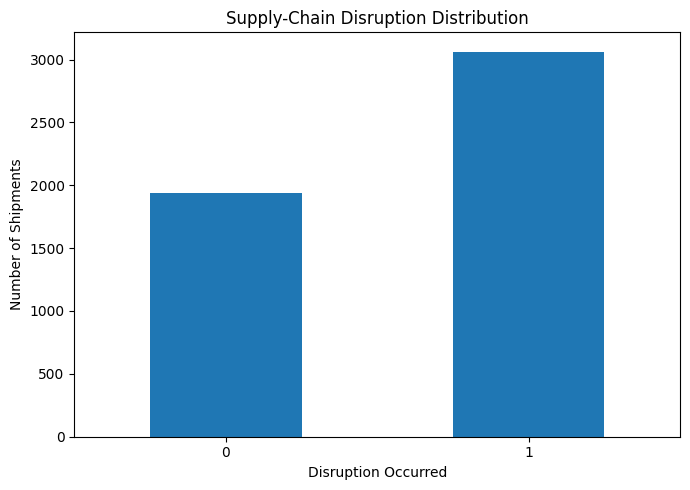

In [8]:
target_counts = (
    supply["Disruption_Occurred"]
    .value_counts()
    .sort_index()
)

target_percent = (
    supply["Disruption_Occurred"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percent.round(2)
})

display(target_summary)

plt.figure(figsize=(7, 5))
target_counts.plot(kind="bar")
plt.title("Supply-Chain Disruption Distribution")
plt.xlabel("Disruption Occurred")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / "disruption_distribution.png", dpi=200)
plt.show()


## Cell 8 — Transport Mode Distribution

,shipment_count
Transport_Mode,
Air,1320
Sea,1281
Road,1214
Rail,1185


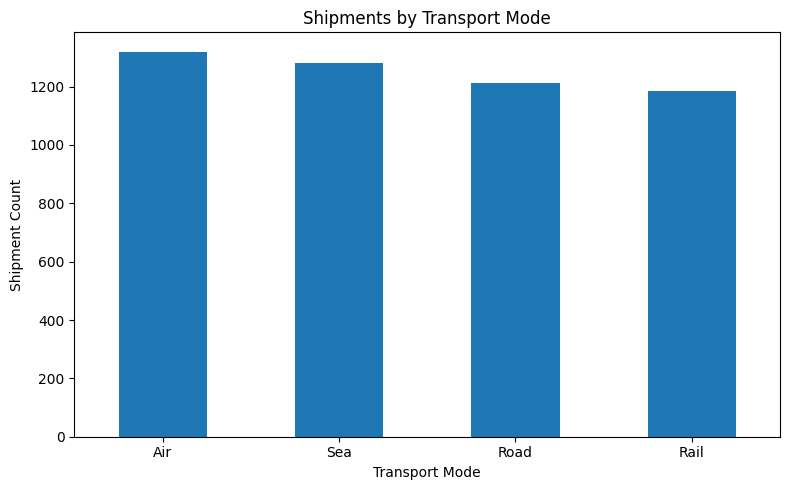

In [9]:
transport_counts = (
    supply["Transport_Mode"]
    .value_counts()
)

display(transport_counts.to_frame("shipment_count"))

plt.figure(figsize=(8, 5))
transport_counts.plot(kind="bar")
plt.title("Shipments by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Shipment Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / "transport_mode_distribution.png", dpi=200)
plt.show()


## Cell 9 — Product Category Distribution

,shipment_count
Product_Category,
Electronics,1016
Textiles,1010
Perishables,1009
Pharmaceuticals,1006
Automotive,959


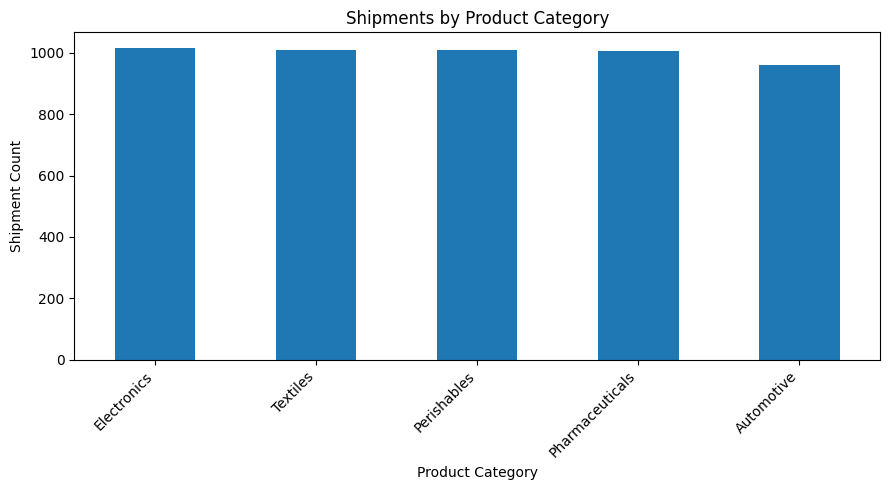

In [10]:
product_counts = (
    supply["Product_Category"]
    .value_counts()
)

display(product_counts.to_frame("shipment_count"))

plt.figure(figsize=(9, 5))
product_counts.plot(kind="bar")
plt.title("Shipments by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Shipment Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "product_category_distribution.png", dpi=200)
plt.show()


## Cell 10 — Weather Condition Distribution

,shipment_count
Weather_Condition,
Fog,1036
Storm,1002
Clear,995
Hurricane,990
Rain,977


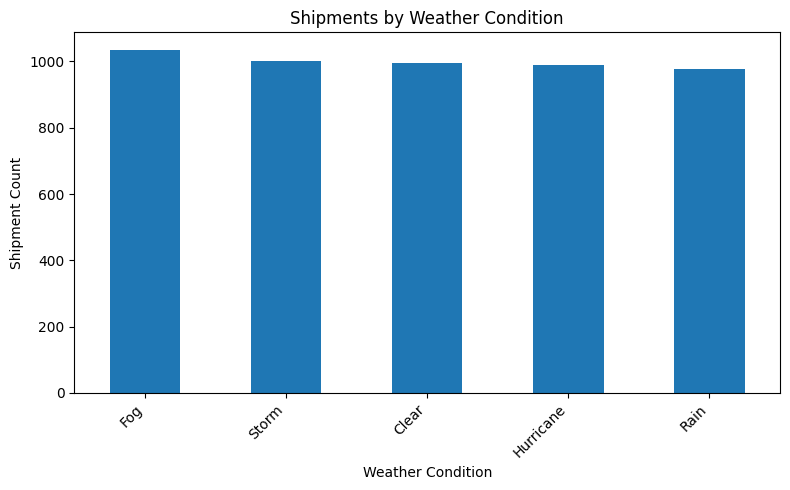

In [11]:
weather_counts = (
    supply["Weather_Condition"]
    .value_counts()
)

display(weather_counts.to_frame("shipment_count"))

plt.figure(figsize=(8, 5))
weather_counts.plot(kind="bar")
plt.title("Shipments by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Shipment Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "weather_distribution.png", dpi=200)
plt.show()


## Cell 11 — Disruption Rate by Transport Mode

,count,mean,disruption_rate_percent
Transport_Mode,,,
Air,1320,0.617424,61.74
Rail,1185,0.611814,61.18
Sea,1281,0.610461,61.05
Road,1214,0.610379,61.04


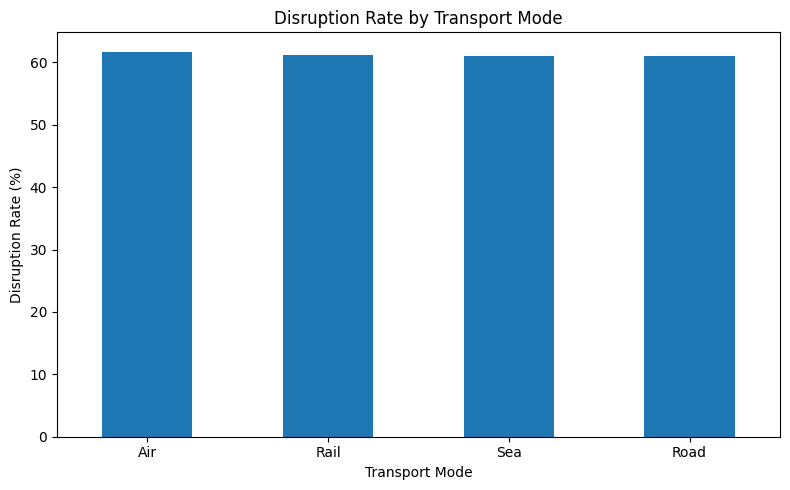

In [12]:
transport_disruption = (
    supply.groupby("Transport_Mode")["Disruption_Occurred"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

transport_disruption["disruption_rate_percent"] = (
    transport_disruption["mean"] * 100
).round(2)

display(transport_disruption)

plt.figure(figsize=(8, 5))
transport_disruption["disruption_rate_percent"].plot(kind="bar")
plt.title("Disruption Rate by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Disruption Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / "disruption_rate_transport_mode.png", dpi=200)
plt.show()


## Cell 12 — Disruption Rate by Weather Condition

,count,mean,disruption_rate_percent
Weather_Condition,,,
Hurricane,990,1.000000,100.00
Storm,1002,0.795409,79.54
Fog,1036,0.480695,48.07
Rain,977,0.419652,41.97
Clear,995,0.369849,36.98


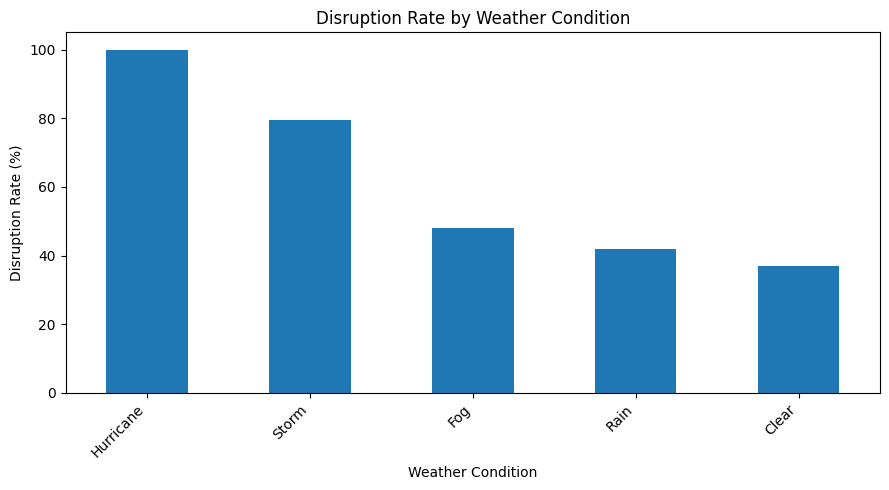

In [13]:
weather_disruption = (
    supply.groupby("Weather_Condition")["Disruption_Occurred"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

weather_disruption["disruption_rate_percent"] = (
    weather_disruption["mean"] * 100
).round(2)

display(weather_disruption)

plt.figure(figsize=(9, 5))
weather_disruption["disruption_rate_percent"].plot(kind="bar")
plt.title("Disruption Rate by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Disruption Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "disruption_rate_weather.png", dpi=200)
plt.show()


## Cell 13 — Numerical Features by Disruption Status

In [14]:
feature_by_target = (
    supply.groupby("Disruption_Occurred")[supply_numeric]
    .mean()
    .T
)

feature_by_target.columns = [
    "No_Disruption_Mean",
    "Disruption_Mean"
]

display(feature_by_target)


,No_Disruption_Mean,Disruption_Mean
Distance_km,7651.761440,7737.139252
Weight_MT,243.970299,247.695002
Fuel_Price_Index,2.850077,2.857382
Geopolitical_Risk_Score,4.262158,5.592132
Carrier_Reliability_Score,0.768714,0.745327
Lead_Time_Days,8.885183,25.976601


## Cell 14 — Lead Time by Disruption Status

,count,mean,median,std,min,max
Disruption_Occurred,,,,,,
0,1937,8.885183,6.24,9.926030,0.5,85.02
1,3063,25.976601,10.69,37.877449,0.5,236.39


<Figure size 800x500 with 0 Axes>

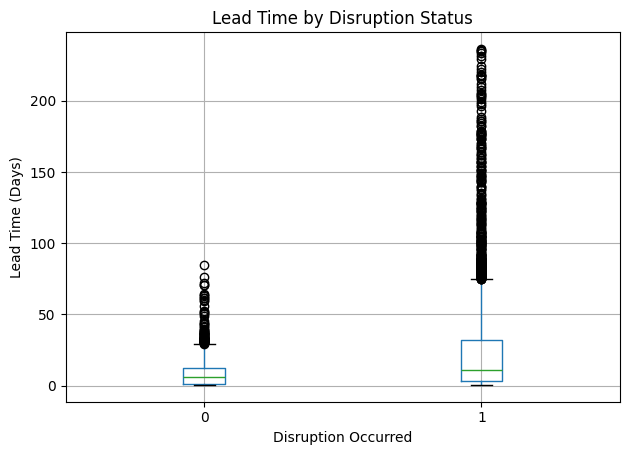

In [15]:
lead_time_summary = (
    supply.groupby("Disruption_Occurred")["Lead_Time_Days"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

display(lead_time_summary)

plt.figure(figsize=(8, 5))
supply.boxplot(
    column="Lead_Time_Days",
    by="Disruption_Occurred"
)
plt.title("Lead Time by Disruption Status")
plt.suptitle("")
plt.xlabel("Disruption Occurred")
plt.ylabel("Lead Time (Days)")
plt.tight_layout()
plt.savefig(FIGURES / "lead_time_by_disruption.png", dpi=200)
plt.show()


## Cell 15 — Geopolitical Risk by Disruption Status

,count,mean,median,std,min,max
Disruption_Occurred,,,,,,
0,1937,4.262158,4.0,2.827524,0.0,10.0
1,3063,5.592132,5.8,2.789378,0.0,10.0


<Figure size 800x500 with 0 Axes>

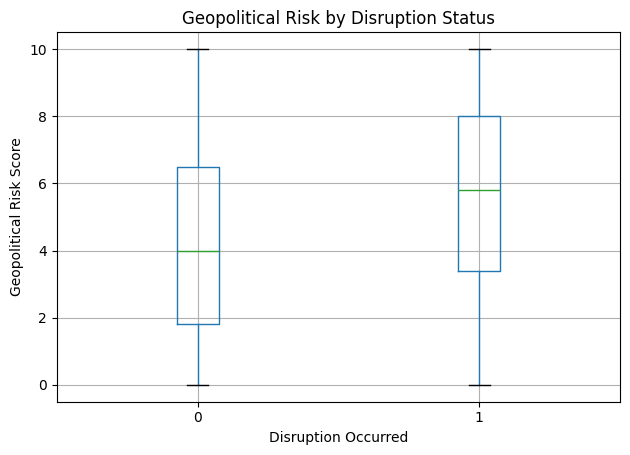

In [16]:
risk_summary = (
    supply.groupby("Disruption_Occurred")["Geopolitical_Risk_Score"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

display(risk_summary)

plt.figure(figsize=(8, 5))
supply.boxplot(
    column="Geopolitical_Risk_Score",
    by="Disruption_Occurred"
)
plt.title("Geopolitical Risk by Disruption Status")
plt.suptitle("")
plt.xlabel("Disruption Occurred")
plt.ylabel("Geopolitical Risk Score")
plt.tight_layout()
plt.savefig(FIGURES / "geopolitical_risk_by_disruption.png", dpi=200)
plt.show()


## Cell 16 — Carrier Reliability by Disruption Status

,count,mean,median,std,min,max
Disruption_Occurred,,,,,,
0,1937,0.768714,0.781,0.145410,0.5,1.0
1,3063,0.745327,0.741,0.142981,0.5,1.0


<Figure size 800x500 with 0 Axes>

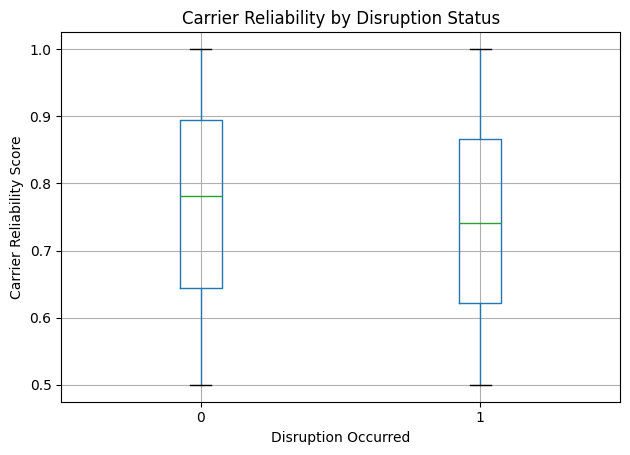

In [17]:
carrier_summary = (
    supply.groupby("Disruption_Occurred")["Carrier_Reliability_Score"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

display(carrier_summary)

plt.figure(figsize=(8, 5))
supply.boxplot(
    column="Carrier_Reliability_Score",
    by="Disruption_Occurred"
)
plt.title("Carrier Reliability by Disruption Status")
plt.suptitle("")
plt.xlabel("Disruption Occurred")
plt.ylabel("Carrier Reliability Score")
plt.tight_layout()
plt.savefig(FIGURES / "carrier_reliability_by_disruption.png", dpi=200)
plt.show()


## Cell 17 — Supply Chain Correlation Matrix

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
Distance_km,1.000,-0.007,-0.010,0.029,-0.011,0.336,0.010
Weight_MT,-0.007,1.000,-0.023,-0.001,0.010,-0.006,0.013
Fuel_Price_Index,-0.010,-0.023,1.000,0.007,-0.027,-0.010,0.004
Geopolitical_Risk_Score,0.029,-0.001,0.007,1.000,0.010,0.088,0.225
Carrier_Reliability_Score,-0.011,0.010,-0.027,0.010,1.000,-0.009,-0.079
Lead_Time_Days,0.336,-0.006,-0.010,0.088,-0.009,1.000,0.265
Disruption_Occurred,0.010,0.013,0.004,0.225,-0.079,0.265,1.000


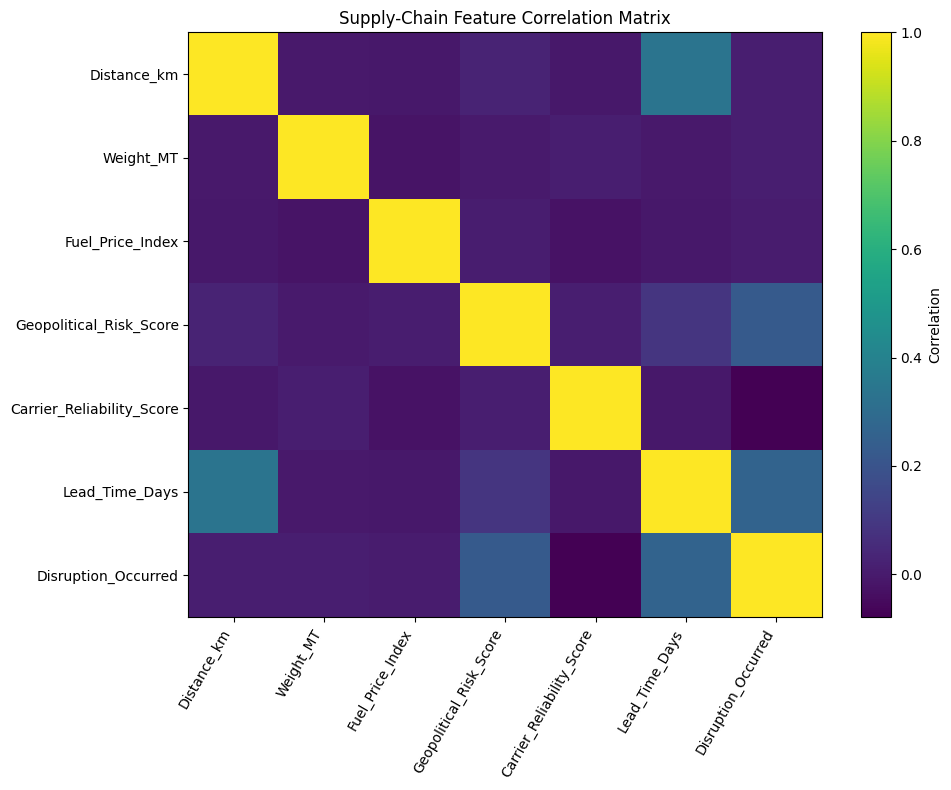

In [18]:
corr = supply[supply_numeric + ["Disruption_Occurred"]].corr()

display(corr.round(3))

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=60,
    ha="right"
)
plt.yticks(
    range(len(corr.columns)),
    corr.columns
)
plt.title("Supply-Chain Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURES / "supply_chain_correlation.png", dpi=200)
plt.show()


## Cell 18 — Monthly Disruption Trend

,count,sum,mean,disruption_rate_percent
Date,,,,
2024-01-01,173,110,0.635838,63.583815
2024-02-01,195,110,0.564103,56.410256
2024-03-01,220,125,0.568182,56.818182
2024-04-01,229,143,0.624454,62.445415
2024-05-01,211,132,0.625592,62.559242
2024-06-01,208,141,0.677885,67.788462
2024-07-01,174,100,0.574713,57.471264
2024-08-01,199,131,0.658291,65.829146
2024-09-01,210,129,0.614286,61.428571


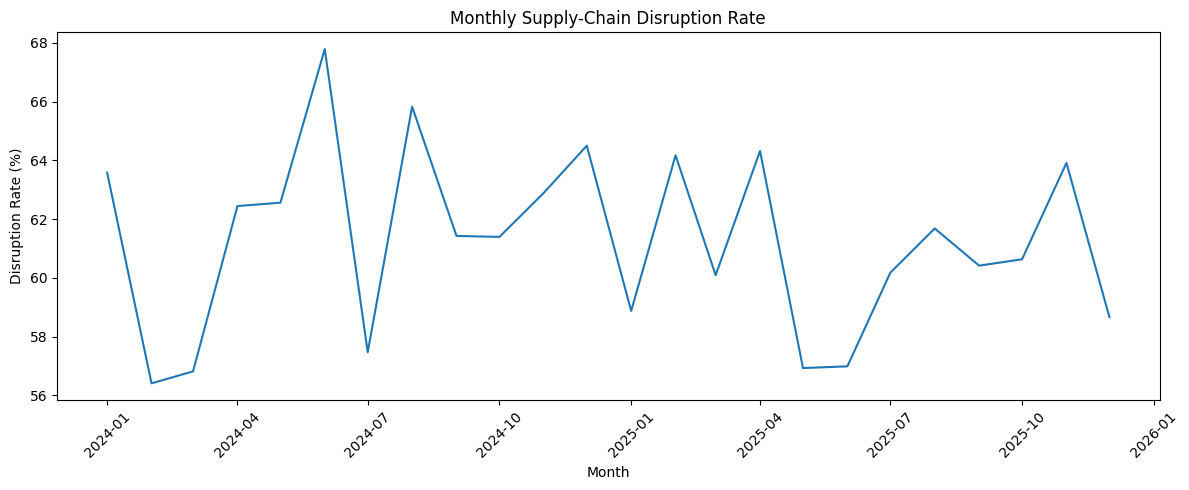

In [19]:
monthly_disruption = (
    supply.set_index("Date")
    .resample("MS")["Disruption_Occurred"]
    .agg(["count", "sum", "mean"])
)

monthly_disruption["disruption_rate_percent"] = (
    monthly_disruption["mean"] * 100
)

display(monthly_disruption)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_disruption.index,
    monthly_disruption["disruption_rate_percent"]
)
plt.title("Monthly Supply-Chain Disruption Rate")
plt.xlabel("Month")
plt.ylabel("Disruption Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES / "monthly_disruption_rate.png", dpi=200)
plt.show()


## Cell 19 — Historical Dataset Summary

In [20]:
historical_summary = []

for file_name, df in historical.items():
    historical_summary.append({
        "dataset": file_name,
        "rows": len(df),
        "columns": len(df.columns),
        "missing_cells": int(df.isna().sum().sum())
    })

historical_summary = pd.DataFrame(historical_summary)

display(historical_summary)


,dataset,rows,columns,missing_cells
0,cleaned_commodity_prices_supply_chain.csv,110515,8,0
1,cleaned_disruption_events.csv,58,18,0
2,cleaned_industry_exposure.csv,250,15,0
3,cleaned_port_congestion.csv,6260,11,0
4,cleaned_shipping_rates.csv,300,14,0
5,cleaned_tariff_timeline.csv,71,17,0
6,cleaned_trade_flows.csv,1250,12,0


## Cell 20 — Historical Numeric Feature Summary

In [21]:
for file_name, df in historical.items():

    numeric = df.select_dtypes(include=np.number)

    print("\n" + "=" * 80)
    print(file_name)
    print("=" * 80)

    if numeric.empty:
        print("No numeric columns.")
    else:
        display(numeric.describe().T)



cleaned_commodity_prices_supply_chain.csv


,count,mean,std,min,25%,50%,75%,max
year,110515.0,2018.080822,4.627354,2010.00,2014.00000,2018.0000,2022.00000,2026.000
month,110515.0,6.443261,3.460975,1.00,3.00000,6.0000,9.00000,12.000
price,110515.0,7488.546375,21334.264863,0.01,14.59055,641.8805,3099.35735,268721.317



cleaned_disruption_events.csv


,count,mean,std,min,25%,50%,75%,max
year,58.0,2018.672414,6.416503,2001.00,2016.0000,2021.000,2023.0000,2025.00
duration_days,58.0,229.275862,282.595166,1.00,60.0000,180.000,365.0000,1825.00
bdi_shock_pct,58.0,-5.620690,11.645084,-60.00,-8.0000,-5.000,-3.0000,40.00
freight_rate_shock_pct,58.0,9.344828,47.327731,-60.00,-15.0000,1.500,15.0000,200.00
gdp_impact_pct,58.0,-0.346552,0.396575,-1.21,-0.6625,-0.345,-0.0175,0.39
trade_volume_impact_pct,58.0,-2.506897,5.006027,-22.00,-4.6500,-1.750,-0.5250,15.00
recovery_months,58.0,7.620690,8.039001,1.00,1.0000,4.000,12.0000,36.00
is_pandemic,58.0,0.103448,0.307203,0.00,0.0000,0.000,0.0000,1.00
is_geopolitical,58.0,0.379310,0.489453,0.00,0.0000,0.000,1.0000,1.00
is_natural,58.0,0.120690,0.328611,0.00,0.0000,0.000,0.0000,1.00



cleaned_industry_exposure.csv


...

,count,mean,std,min,25%,50%,75%,max
year,300.0,2012.000000,7.223151,2000.000,2006.00000,2012.000,2018.0000,2024.00
month,300.0,6.500000,3.457820,1.000,3.75000,6.500,9.2500,12.00
baltic_dry_index,300.0,2374.113333,1712.922795,300.000,1339.00000,1823.500,2560.7500,9930.00
container_rate_usd_40ft,300.0,2989.133333,1950.802746,1570.000,2130.00000,2390.000,2802.5000,12560.00
air_cargo_rate_usd_kg,300.0,3.956000,0.980450,2.000,3.38000,3.735,4.1425,8.79
bdi_mom_change_pct,300.0,2.437833,41.287714,-45.080,-5.89250,0.000,6.5125,690.00
container_yoy_pct,300.0,7.904300,36.002073,-73.730,-8.34000,1.585,17.1200,193.54
tanker_rate_aframax_usd_day,300.0,26444.463333,10599.641654,8000.000,20642.00000,25715.500,30747.7500,80000.00
bulk_carrier_handysize_usd_day,300.0,11155.036667,4472.017218,3000.000,7926.25000,11254.500,13945.7500,21829.00
supply_chain_pressure_index,300.0,1.098800,0.476570,0.500,0.81000,0.995,1.2300,2.92



cleaned_tariff_timeline.csv


,count,mean,std,min,25%,50%,75%,max
year,71.0,2023.098592,2.819093,2018.0,2020.5,2025.0,2025.0,2026.0
month,71.0,5.211268,2.941892,1.0,3.0,4.0,8.0,12.0
tariff_rate_pct,71.0,28.554930,37.756898,0.0,2.5,24.0,30.0,212.0
estimated_value_usd_bn,71.0,14.116901,40.085387,0.0,0.0,0.0,0.3,200.0
is_trump_1_0,71.0,0.253521,0.438123,0.0,0.0,0.0,0.5,1.0
is_biden,71.0,0.154930,0.364413,0.0,0.0,0.0,0.0,1.0
is_trump_2_0,71.0,0.591549,0.495046,0.0,0.0,1.0,1.0,1.0
is_retaliation,71.0,0.140845,0.350338,0.0,0.0,0.0,0.0,1.0
is_section_232,71.0,0.070423,0.257679,0.0,0.0,0.0,0.0,1.0
is_section_301,71.0,0.084507,0.280126,0.0,0.0,0.0,0.0,1.0



cleaned_trade_flows.csv


,count,mean,std,min,25%,50%,75%,max
year,1250.0,2012.000000,7.213989,2000.00,2006.0000,2012.00,2018.0000,2024.000
trade_value_bn_usd,1250.0,95.483208,120.025818,4.65,31.7425,56.01,85.5725,576.600
yoy_growth_pct,1250.0,2.339048,10.205128,-68.04,-2.9000,1.64,7.0150,217.010
effective_tariff_rate_pct,1250.0,2.780400,2.501236,2.50,2.5000,2.50,2.5000,35.000
trade_active,1250.0,0.980000,0.140056,0.00,1.0000,1.00,1.0000,1.000
supply_chain_integrated,1250.0,0.420000,0.493756,0.00,0.0000,0.00,1.0000,1.000
concentration_risk,1250.0,0.350360,0.117154,0.10,0.2680,0.35,0.4250,0.752
yoy_growth_pct_was_missing,1250.0,0.040000,0.196038,0.00,0.0000,0.00,0.0000,1.000


## Cell 21 — News Sentiment Distribution

,count,percentage
sentiment,,
neutral,2873,59.36
positive,1363,28.16
negative,604,12.48


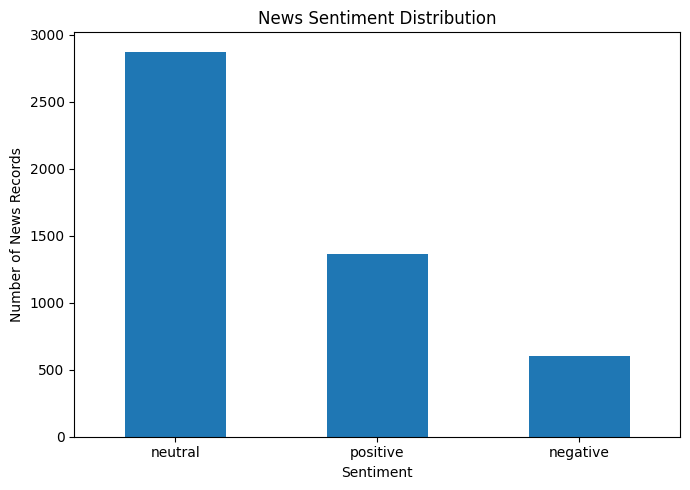

In [22]:
news_sentiment_counts = (
    news["sentiment"]
    .value_counts()
)

news_sentiment_percent = (
    news["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
)

news_sentiment_summary = pd.DataFrame({
    "count": news_sentiment_counts,
    "percentage": news_sentiment_percent.round(2)
})

display(news_sentiment_summary)

plt.figure(figsize=(7, 5))
news_sentiment_counts.plot(kind="bar")
plt.title("News Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of News Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / "sentiment_distribution.png", dpi=200)
plt.show()


## Cell 22 — News Text Length Analysis

In [23]:
news_analysis = news.copy()

news_analysis["text_length"] = (
    news_analysis["text"]
    .astype("string")
    .str.len()
)

news_analysis["word_count"] = (
    news_analysis["text"]
    .astype("string")
    .str.split()
    .str.len()
)

display(
    news_analysis[["text_length", "word_count"]]
    .describe()
)

sentiment_text_length = (
    news_analysis.groupby("sentiment")[["text_length", "word_count"]]
    .mean()
    .sort_values("word_count", ascending=False)
)

display(sentiment_text_length)


,text_length,word_count
count,4840.0,4840.000000
mean,128.067975,23.092975
std,56.413217,9.940827
min,9.0,2.000000
25%,84.0,16.000000
50%,119.0,21.000000
75%,163.0,29.000000
max,315.0,81.000000


,text_length,word_count
sentiment,,
positive,135.640499,24.692590
negative,125.730132,23.917219
neutral,124.966934,22.160808


## Cell 23 — Marketing Descriptive Statistics

In [24]:
marketing_numeric = [
    "Duration",
    "Conversion_Rate",
    "Acquisition_Cost",
    "ROI",
    "Clicks",
    "Impressions",
    "Engagement_Score"
]

display(
    marketing[marketing_numeric].describe().T
)


,count,mean,std,min,25%,50%,75%,max
Duration,200000.0,37.503975,16.746720,15.00,30.00,30.00,45.00,60.00
Conversion_Rate,200000.0,0.080070,0.040602,0.01,0.05,0.08,0.12,0.15
Acquisition_Cost,200000.0,12504.393040,4337.664545,5000.00,8739.75,12496.50,16264.00,20000.00
ROI,200000.0,5.002438,1.734488,2.00,3.50,5.01,6.51,8.00
Clicks,200000.0,549.772030,260.019056,100.00,325.00,550.00,775.00,1000.00
Impressions,200000.0,5507.301520,2596.864286,1000.00,3266.00,5517.50,7753.00,10000.00
Engagement_Score,200000.0,5.494710,2.872581,1.00,3.00,5.00,8.00,10.00


## Cell 24 — Marketing Channel Distribution

,campaign_count
Channel_Used,
Email,33599
Google Ads,33438
YouTube,33392
Instagram,33392
Website,33360
Facebook,32819


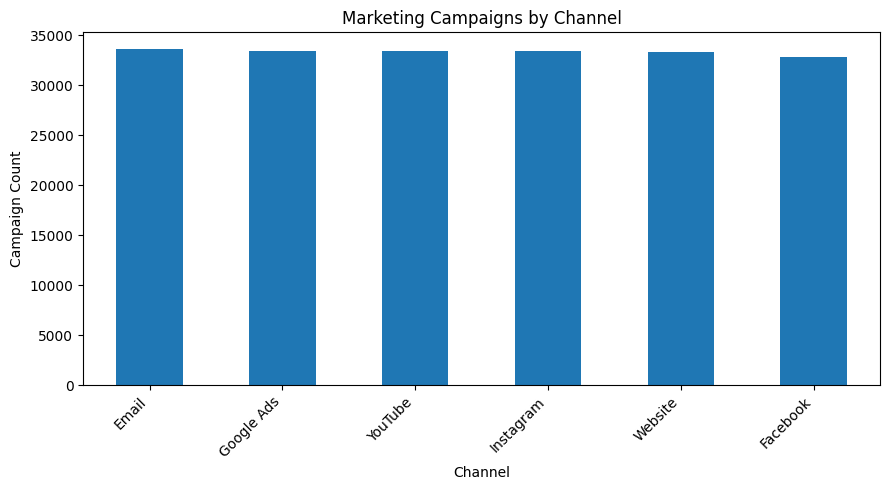

In [25]:
channel_counts = (
    marketing["Channel_Used"]
    .value_counts()
)

display(channel_counts.to_frame("campaign_count"))

plt.figure(figsize=(9, 5))
channel_counts.plot(kind="bar")
plt.title("Marketing Campaigns by Channel")
plt.xlabel("Channel")
plt.ylabel("Campaign Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "marketing_channel_distribution.png", dpi=200)
plt.show()


## Cell 25 — Marketing Performance by Channel

In [26]:
channel_performance = (
    marketing.groupby("Channel_Used")[
        ["Conversion_Rate", "Acquisition_Cost", "ROI", "Engagement_Score"]
    ]
    .mean()
    .sort_values("ROI", ascending=False)
)

display(channel_performance)


,Conversion_Rate,Acquisition_Cost,ROI,Engagement_Score
Channel_Used,,,,
Facebook,0.079992,12510.900942,5.018699,5.503702
Website,0.080183,12487.814748,5.014167,5.508903
Google Ads,0.080183,12528.031401,5.003141,5.494049
Email,0.080282,12526.387809,4.996487,5.487842
YouTube,0.079889,12481.390213,4.993754,5.484937
Instagram,0.079886,12491.760002,4.988706,5.489039


## Cell 26 — Marketing Performance by Campaign Type

In [27]:
campaign_performance = (
    marketing.groupby("Campaign_Type")[
        ["Conversion_Rate", "Acquisition_Cost", "ROI", "Engagement_Score"]
    ]
    .mean()
    .sort_values("ROI", ascending=False)
)

display(campaign_performance)


,Conversion_Rate,Acquisition_Cost,ROI,Engagement_Score
Campaign_Type,,,,
Influencer,0.080315,12507.170330,5.011068,5.483134
Search,0.080021,12498.736459,5.008357,5.487138
Display,0.080089,12508.034461,5.006551,5.505889
Email,0.079788,12495.346100,4.994295,5.499624
Social Media,0.080135,12512.698094,4.991784,5.497878


## Cell 27 — Marketing ROI Distribution

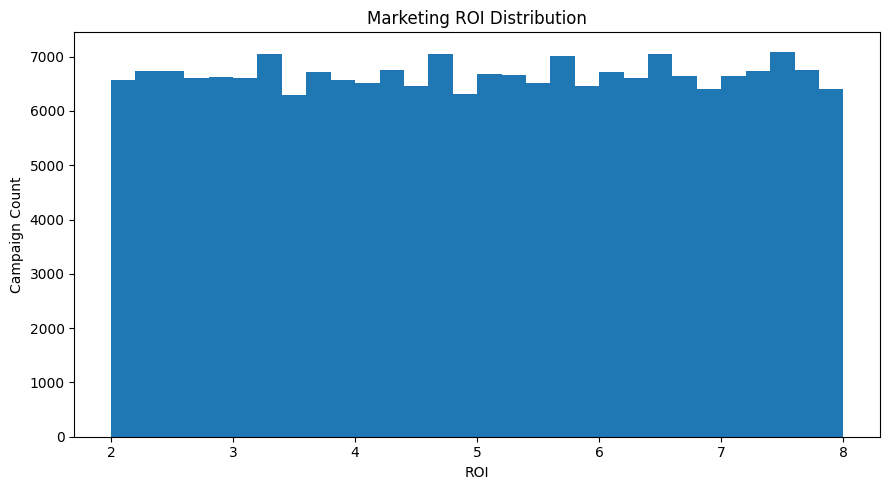

In [28]:
plt.figure(figsize=(9, 5))
marketing["ROI"].plot(kind="hist", bins=30)
plt.title("Marketing ROI Distribution")
plt.xlabel("ROI")
plt.ylabel("Campaign Count")
plt.tight_layout()
plt.savefig(FIGURES / "marketing_roi_distribution.png", dpi=200)
plt.show()


## Cell 28 — Marketing Engagement vs ROI

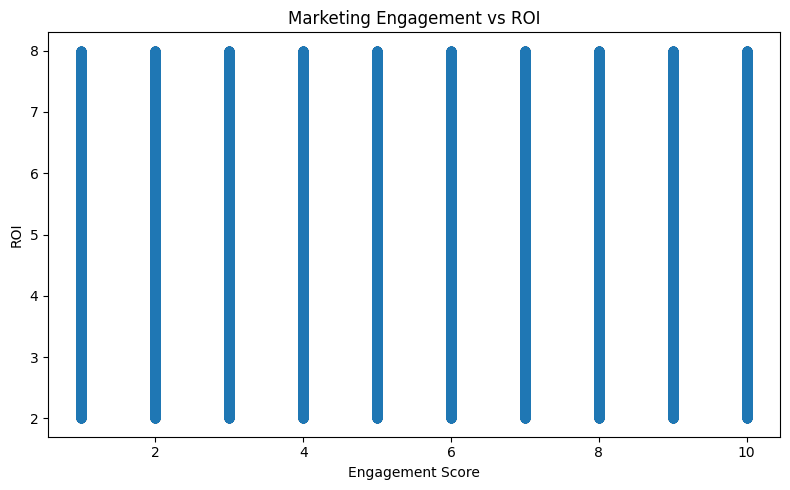

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(
    marketing["Engagement_Score"],
    marketing["ROI"],
    alpha=0.25
)
plt.title("Marketing Engagement vs ROI")
plt.xlabel("Engagement Score")
plt.ylabel("ROI")
plt.tight_layout()
plt.savefig(FIGURES / "engagement_vs_roi.png", dpi=200)
plt.show()


## Cell 29 — Project-Level Descriptive Observations

The following section is intentionally generated from the calculated tables rather than manually claiming specific causal relationships.

The notebook reports:
- supply-chain disruption frequency and distribution;
- disruption rates across transport modes and weather conditions;
- differences in numerical supply-chain variables by disruption status;
- monthly disruption-rate patterns;
- historical trade-data distributions;
- news sentiment composition and text characteristics;
- marketing performance by channel and campaign type.

**Important:** These are exploratory observations only. They do not establish that news sentiment causes disruptions, or that any single feature causes a disruption.


In [30]:
print("EDA summary generated from the calculated results.")

overall_disruption_rate = (
    supply["Disruption_Occurred"].mean() * 100
)

print(
    f"Overall observed shipment disruption rate: "
    f"{overall_disruption_rate:.2f}%"
)

highest_transport = transport_disruption[
    "disruption_rate_percent"
].idxmax()

highest_weather = weather_disruption[
    "disruption_rate_percent"
].idxmax()

print(
    f"Highest observed disruption-rate transport mode: "
    f"{highest_transport}"
)

print(
    f"Highest observed disruption-rate weather category: "
    f"{highest_weather}"
)

highest_roi_channel = channel_performance["ROI"].idxmax()
highest_roi_campaign = campaign_performance["ROI"].idxmax()

print(
    f"Highest mean ROI channel in the supplied marketing data: "
    f"{highest_roi_channel}"
)

print(
    f"Highest mean ROI campaign type in the supplied marketing data: "
    f"{highest_roi_campaign}"
)


EDA summary generated from the calculated results.
Overall observed shipment disruption rate: 61.26%
Highest observed disruption-rate transport mode: Air
Highest observed disruption-rate weather category: Hurricane
Highest mean ROI channel in the supplied marketing data: Facebook
Highest mean ROI campaign type in the supplied marketing data: Influencer


## Cell 30 — Save EDA Tables

In [31]:
TABLES = ROOT / "results" / "eda_tables"
TABLES.mkdir(parents=True, exist_ok=True)

target_summary.to_csv(
    TABLES / "disruption_target_summary.csv"
)

transport_disruption.to_csv(
    TABLES / "disruption_by_transport_mode.csv"
)

weather_disruption.to_csv(
    TABLES / "disruption_by_weather.csv"
)

feature_by_target.to_csv(
    TABLES / "features_by_disruption_status.csv"
)

monthly_disruption.to_csv(
    TABLES / "monthly_disruption.csv"
)

news_sentiment_summary.to_csv(
    TABLES / "news_sentiment_summary.csv"
)

channel_performance.to_csv(
    TABLES / "marketing_channel_performance.csv"
)

campaign_performance.to_csv(
    TABLES / "marketing_campaign_performance.csv"
)

historical_summary.to_csv(
    TABLES / "historical_dataset_summary.csv",
    index=False
)

print("EDA tables saved to:", TABLES)


EDA tables saved to: c:\Users\ankit\Desktop\Ml-Project\AI-Supply-Chain-Digital-Marketing-v1\results\eda_tables


## Cell 31 — Final EDA Checklist

In [32]:
checks = {
    "Supply data loaded": supply.shape == (5000, 14),
    "Marketing data loaded": marketing.shape == (200000, 16),
    "News data loaded": news.shape == (4840, 2),
    "Supply missing cells": int(supply.isna().sum().sum()),
    "Marketing missing cells": int(marketing.isna().sum().sum()),
    "News missing cells": int(news.isna().sum().sum()),
    "Figures directory exists": FIGURES.exists()
}

display(pd.Series(checks, name="value").to_frame())

print("\n03_eda.ipynb completed.")
print("Next notebook: 04_nlp_news_processing.ipynb")


,value
Supply data loaded,True
Marketing data loaded,True
News data loaded,True
Supply missing cells,0
Marketing missing cells,0
News missing cells,0
Figures directory exists,True



03_eda.ipynb completed.
Next notebook: 04_nlp_news_processing.ipynb
